# Лабораторная работа по оптимизации

Заполните ниже цель работы, теорию и решения задач.

---



## Цель работы

Исследовать метод штрафных функций (метод внешней точки) для решения задачи условной оптимизации и проиллюстрировать релаксационную последовательность решений при $r \to \infty$ в двумерном и трёхмерном случаях.



## Теория (кратко)

Рассматривается задача условной оптимизации

$$\min f(x), \quad g(x) \le 0, \; x \in \mathbb{R}^2.$$

В методе внешних штрафных функций вводится вспомогательная функция

$$Q(x, r) = f(x) + r\,G(g(x)), \quad r > 0,$$

где $G(g(x)) > 0$ при нарушении ограничения $g(x) > 0$ и $G(g(x)) = 0$ в допустимой области $g(x) \le 0$. При $r \to \infty$ решение задачи безусловной оптимизации $\min Q(x,r)$ стремится к решению исходной задачи с ограничением.



In [ ]:
using LinearAlgebra
using Plots

gr()

# -------------------------
# Задача 1D: R -> R
# -------------------------
# Цель: min f1(x),  ограничение g1(x) <= 0
# Берем: f1(x) = (x - 2)^2,  g1(x) = x - 1 <= 0 (то есть x <= 1)
f1(x) = (x - 2.0)^2
g1(x) = x - 1.0
G1(s) = max(0.0, s)^2
Q1(x, r) = f1(x) + r * G1(g1(x))

# -------------------------
# Задача 2D: R^2 -> R
# -------------------------
# Цель: min f2(x1, x2),  ограничение g2(x1, x2) <= 0
# Берем эллиптический параболоид и линейное ограничение
function f2(x::AbstractVector; α::Real=1.0, β::Real=2.0)
    return α * (x[1] - 2.0)^2 + β * (x[2] - 2.0)^2
end

function g2(x::AbstractVector)
    # допустимая область: x1 + x2 <= 2
    return x[1] + x[2] - 2.0
end

G2(s) = max(0.0, s)^2

function Q2(x::AbstractVector, r::Real; α::Real=1.0, β::Real=2.0)
    return f2(x; α=α, β=β) + r * G2(g2(x))
end

function ∇f2(x::AbstractVector; α::Real=1.0, β::Real=2.0)
    return [2α * (x[1] - 2.0), 2β * (x[2] - 2.0)]
end

function ∇Q2(x::AbstractVector, r::Real; α::Real=1.0, β::Real=2.0)
    s = g2(x)
    if s > 0
        # grad(r * s^2) = 2 r s * grad(g2), grad(g2) = (1, 1)
        return ∇f2(x; α=α, β=β) + 2r * s .* [1.0, 1.0]
    else
        return ∇f2(x; α=α, β=β)
    end
end

function gradient_descent_2d(x0::AbstractVector, r::Real;
                             α::Real=1.0, β::Real=2.0,
                             η::Real=0.02, max_iter::Int=5000, tol::Real=1e-8)
    x = collect(Float64, x0)
    for _ in 1:max_iter
        grad = ∇Q2(x, r; α=α, β=β)
        if norm(grad) < tol
            break
        end
        x_new = x - η * grad
        if norm(x_new - x) < tol
            x = x_new
            break
        end
        x = x_new
    end
    return x
end



gradient_descent_penalty (generic function with 1 method)

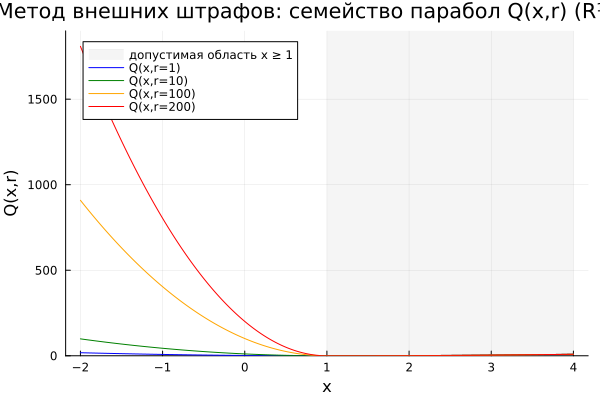

In [ ]:
# Одномерный случай: R¹ -> R² (на графике семейство парабол Q(x,r))

rs1 = [1.0, 10.0, 100.0, 200.0]
colors1 = [:blue, :green, :orange, :red]

# Берем более узкий диапазон, чтобы формы парабол хорошо читались
x_range1 = range(-0.5, 2.5, length=600)

p1d = plot(xlabel="x", ylabel="Q(x,r)",
           title="Метод внешних штрафов: семейство парабол Q(x,r)",
           legend=:topright, linewidth=2)

# Допустимая область g1(x) <= 0 -> x <= 1
vspan!(p1d, [-0.5, 1.0], alpha=0.10, color=:gray, label="допустимая область x ≤ 1")

for (i, r) in enumerate(rs1)
    y = [Q1(x, r) for x in x_range1]
    plot!(p1d, x_range1, y, color=colors1[i], label="Q(x, r=$(Int(r)))")
end

# Граница ограничения x = 1
vline!(p1d, [1.0], color=:black, linewidth=2, linestyle=:dash, label="g1(x)=0")

p1d

┌ Warning: Multiple series with different color share a colorbar.
│ Colorbar may not reflect all series correctly.
└ @ Plots C:\Users\User\.julia\packages\Plots\ywg93\src\backends\gr.jl:530
┌ Warning: Multiple series with different fill alpha share a colorbar.
│ Colorbar may not reflect all series correctly.
└ @ Plots C:\Users\User\.julia\packages\Plots\ywg93\src\backends\gr.jl:530
┌ Warning: Multiple series with different color share a colorbar.
│ Colorbar may not reflect all series correctly.
└ @ Plots C:\Users\User\.julia\packages\Plots\ywg93\src\backends\gr.jl:530
┌ Warning: Multiple series with different fill alpha share a colorbar.
│ Colorbar may not reflect all series correctly.
└ @ Plots C:\Users\User\.julia\packages\Plots\ywg93\src\backends\gr.jl:530
┌ Warning: Multiple series with different color share a colorbar.
│ Colorbar may not reflect all series correctly.
└ @ Plots C:\Users\User\.julia\packages\Plots\ywg93\src\backends\gr.jl:530


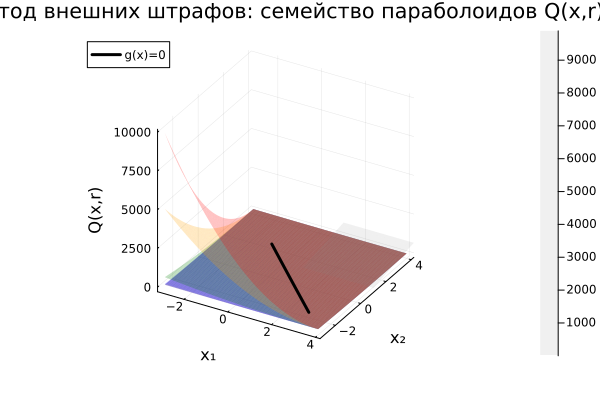

┌ Warning: Multiple series with different fill alpha share a colorbar.
│ Colorbar may not reflect all series correctly.
└ @ Plots C:\Users\User\.julia\packages\Plots\ywg93\src\backends\gr.jl:530
invalid number of domain values
invalid number of domain values
invalid number of domain values


In [ ]:
# Двумерный случай: R² -> R³ (на графике семейство параболоидов Q(x,r))

α = 1.0
β = 2.0
rs2 = [1.0, 10.0, 100.0, 200.0]
colors2 = [:blue, :green, :orange, :red]

# Диапазон уже около границы, чтобы было видно форму параболоидов
x1_range = range(-0.5, 2.5, length=70)
x2_range = range(-0.5, 2.5, length=70)

# Базовая поверхность f2
Zf = [f2([x1, x2]; α=α, β=β) for x2 in x2_range, x1 in x1_range]

p3d = surface(x1_range, x2_range, Zf,
              alpha=0.35, c=:gray, colorbar=false,
              xlabel="x₁", ylabel="x₂", zlabel="Q(x,r)",
              title="Метод внешних штрафов: семейство параболоидов Q(x,r)",
              label="f2(x)")

# Параболоиды Q2(x,r)
for (i, r) in enumerate(rs2)
    Zq = [Q2([x1, x2], r; α=α, β=β) for x2 in x2_range, x1 in x1_range]
    surface!(p3d, x1_range, x2_range, Zq,
             alpha=0.22, c=colors2[i], colorbar=false,
             label="Q2(x,r=$(Int(r)))")
end

# Линия границы ограничения: g2(x)=0 -> x1 + x2 = 2
x1_line = range(-0.3, 2.3, length=120)
x2_line = 2.0 .- x1_line
z_line = [minimum([Q2([x1, x2], r; α=α, β=β) for r in rs2]) for (x1, x2) in zip(x1_line, x2_line)]
plot!(p3d, x1_line, x2_line, z_line, color=:black, linewidth=3, label="g2(x)=0")

# Допустимая область: g2(x)<=0 -> x1 + x2 <= 2 (показываем в проекции снизу)
x_feas = [-0.5, 2.0, -0.5]
y_feas = [-0.5, -0.5, 2.0]
z0 = minimum(Zf) - 0.2
surface!(p3d, x_feas, y_feas, fill(z0, 3),
         alpha=0.15, c=:black, colorbar=false, label="область g2(x) ≤ 0")

# Минимумы Q2 для каждого r
x0 = [2.2, 2.2]
for (i, r) in enumerate(rs2)
    x_star = gradient_descent_2d(x0, r; α=α, β=β)
    scatter!(p3d, [x_star[1]], [x_star[2]], [Q2(x_star, r; α=α, β=β)],
             marker=:circle, markersize=5, color=colors2[i],
             label="min r=$(Int(r))")
end

p3d